# Evaluating Model on Unseen Data

# Tools and Utils

In [32]:
# ----import tools----

#Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset
from huggingface_hub import login

# MLflow
import mlflow
import mlflow.transformers
from mlflow.tracking import MlflowClient

#text processing
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


# Tensorflow and Keras and torch
import tensorflow as tf
import numpy as np
import torch
from torch.utils.data import DataLoader

#evaluation
import evaluate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## A. Fetch Test Data

In [2]:
# load the data set
login()
source = "OtabekRizayev/scam-data"
ds = load_dataset(source, split="train")

# show the data set
print(ds)


Dataset({
    features: ['Unnamed: 0', 'text', 'label'],
    num_rows: 39999
})


## B.Inspect Test Data

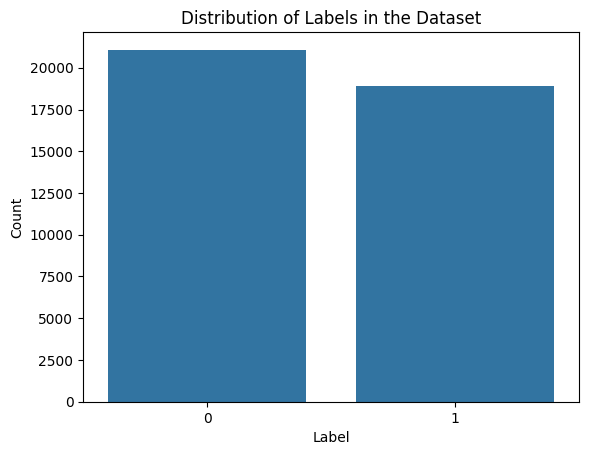

label
0    21082
1    18917
Name: count, dtype: int64

In [3]:
# check data set distribution
def check_dataset_distribution(dataset):
    dataset_df = pd.DataFrame(dataset)
    sns.countplot(x="label", data=dataset_df)
    plt.title("Distribution of Labels in the Dataset")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()

    return dataset_df["label"].value_counts()

check_dataset_distribution(ds)

In [4]:
def undersample_datset(dataset):
    # Convert the dataset to a DataFrame for easier manipulation
    df = pd.DataFrame(dataset)

    # Separate the majority and minority classes
    majority_class = df[df['label'] == 0]
    minority_class = df[df['label'] == 1]

    # Undersample the majority class
    majority_undersampled = majority_class.sample(len(minority_class), random_state=42)

    # Combine the undersampled majority class with the minority class
    balanced_df = pd.concat([majority_undersampled, minority_class])

    # Shuffle the balanced dataset
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Convert back to a Hugging Face Dataset
    balanced_dataset = Dataset.from_pandas(balanced_df)

    return balanced_dataset
    

balanced_ds = undersample_datset(ds)
print(balanced_ds)

Dataset({
    features: ['Unnamed: 0', 'text', 'label'],
    num_rows: 37834
})


In [14]:
# reduce the data set size for faster training
balanced_ds = balanced_ds.shuffle(seed=42).select(range(1000))
print(balanced_ds)

Dataset({
    features: ['Unnamed: 0', 'text', 'label'],
    num_rows: 1000
})


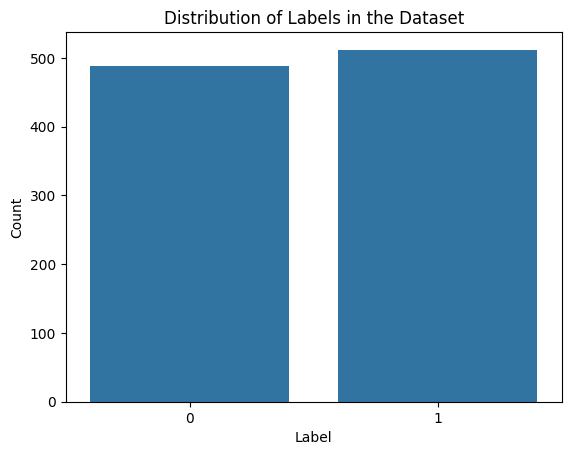

label
1    512
0    488
Name: count, dtype: int64

In [15]:
check_dataset_distribution(balanced_ds)

In [16]:
def check_random_samples(dataset, num_samples=5):
    print("Random Samples from the Dataset:")
    for i in range(num_samples):
        random_index = np.random.randint(0, len(dataset))
        sample = dataset[random_index]
        
        print(f"Sample {i+1}:")
        print(f"Label: {sample['label']}")
        print(f"Text: {sample['text']}")
        print("-" * 50)
        
check_random_samples(balanced_ds, 5)

Random Samples from the Dataset:
Sample 1:
Label: 1
Text: Important notice: Your tax refund requires urgent attention. Act without delay to avoid issues. Ref: 985
--------------------------------------------------
Sample 2:
Label: 0
Text: Get your hands on a free laptop! now and enjoy exclusive benefits. Code: 4459
--------------------------------------------------
Sample 3:
Label: 0
Text: Get your hands on a free laptop! this instant and enjoy exclusive benefits. Code: 5940
--------------------------------------------------
Sample 4:
Label: 0
Text: Claim a free vacation! right away and enjoy exclusive benefits. Code: 5950
--------------------------------------------------
Sample 5:
Label: 1
Text: Important notice: Your prize claim requires urgent attention. Act without delay to avoid issues. Ref: 4439
--------------------------------------------------


## C.distil-mBERT

### Load model from MLflow

In [9]:
# set tracking uri
mlflow.set_tracking_uri("http://localhost:8080")
# load the model and tokenizer from mlflow
distilmbert_model_run_id = "runs:/4b367643a71244478d7946e4f7685d2d/mBERT_LORA"

# load component from mlflow
components = mlflow.transformers.load_model(distilmbert_model_run_id)
bert_lora = components.model
tokenizer = components.tokenizer

2026/05/03 19:32:45 INFO mlflow.transformers: 'runs:/4b367643a71244478d7946e4f7685d2d/mBERT_LORA' resolved as 'mlflow-artifacts:/1/4b367643a71244478d7946e4f7685d2d/artifacts/mBERT_LORA'


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Tokenize

In [17]:
# tokenize the data set
tokenized_ds = balanced_ds.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length"),
    batched=True,
)

# prepare the data for inference
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print(tokenized_ds)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1000
})


### Predict + Inference Compute Time

In [41]:
import time

total_time = 0
total_samples = 0

#MPS
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# predict the labels
loader = DataLoader(tokenized_ds, batch_size=16)
predictions = []
bert_lora.eval()

with torch.no_grad():
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        start_time = time.time()
        outputs = bert_lora(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        batch_predictions = torch.argmax(logits, dim=-1)
        predictions.extend(batch_predictions.cpu())

        end_time = time.time()
        total_time += (end_time - start_time)
        total_samples += input_ids.size(0)

        print(f"progress:{len(predictions)}/{len(tokenized_ds)}")
        print(f"average inference time per sample: {total_time/total_samples:.4f} seconds")


progress:16/1000
average inference time per sample: 0.0617 seconds
progress:32/1000
average inference time per sample: 0.0564 seconds
progress:48/1000
average inference time per sample: 0.0548 seconds
progress:64/1000
average inference time per sample: 0.0536 seconds
progress:80/1000
average inference time per sample: 0.0529 seconds
progress:96/1000
average inference time per sample: 0.0524 seconds
progress:112/1000
average inference time per sample: 0.0520 seconds
progress:128/1000
average inference time per sample: 0.0517 seconds
progress:144/1000
average inference time per sample: 0.0516 seconds
progress:160/1000
average inference time per sample: 0.0515 seconds
progress:176/1000
average inference time per sample: 0.0518 seconds
progress:192/1000
average inference time per sample: 0.0519 seconds
progress:208/1000
average inference time per sample: 0.0517 seconds
progress:224/1000
average inference time per sample: 0.0517 seconds
progress:240/1000
average inference time per sample: 0

### Number of Params

In [42]:
num_params = bert_lora.num_parameters()
memory_size = bert_lora.get_memory_footprint() / (1024**2)

mBERT_characteristics = {
    "num_parameters": num_params,
    "memory_size_MB": memory_size,
    "average_inference_time_per_sample_sec": total_time / total_samples,
}

print(mBERT_characteristics)

{'num_parameters': 136213252, 'memory_size_MB': 519.6162261962891, 'average_inference_time_per_sample_sec': 0.05362528443336487}


In [45]:
print("label vs prediction", list(zip(tokenized_ds["labels"], predictions)))

label vs prediction [(tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(1), tensor(0)), (tensor(0), tensor(1)), (tensor(1), tensor(0)), (tensor(0), tensor(

### Classification Report

In [46]:
def compute_metrics(predictions, references):
    accuracy = accuracy_score(references, predictions)
    precision = precision_score(references, predictions)
    recall = recall_score(references, predictions)
    f1 = f1_score(references, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }

# compute metrics
references = tokenized_ds["labels"]
metrics = compute_metrics(predictions, references)
print(metrics)

{'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}


### Confusion Metric

### F Beta Score

### Calibration Curve

### False Prediction Confidence Distribution